In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# Download only if the local dataset does not exist
if Path("titanic.csv").exists():
    df = pd.read_csv("titanic.csv")
else:
    df = sns.load_dataset("titanic")
    df.to_csv("titanic.csv", index=False)

print("Dataset shape:", df.shape)

df.info()
display(df.describe(include="all"))
display(df.head())

print("\nMissing values (%):")
missing = df.isnull().mean() * 100
print(missing[missing > 0].sort_values(ascending=False))

print("\nSurvival class balance (%):")
print(df["survived"].value_counts(normalize=True) * 100)

Dataset shape: (891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Missing values (%):
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64

Survival class balance (%):
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [4]:
# Check missing values
missing_pct = df.isna().mean() * 100

for column, percentage in missing_pct.items():
    if percentage > 0:
        print(f"{column}: {percentage:.2f}%")

# Remove deck
df = df.drop(columns=["deck"])

# Fill missing ages with the median
df["age"] = df["age"].fillna(df["age"].median())

# Remove missing embarkation rows
df = df.dropna(
    subset=["embarked", "embark_town"]
).copy()

# Save cleaned dataset separately
df.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned shape:", df.shape)
print(df.isnull().sum())

age: 19.87%
embarked: 0.22%
deck: 77.22%
embark_town: 0.22%
Cleaned shape: (889, 14)
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


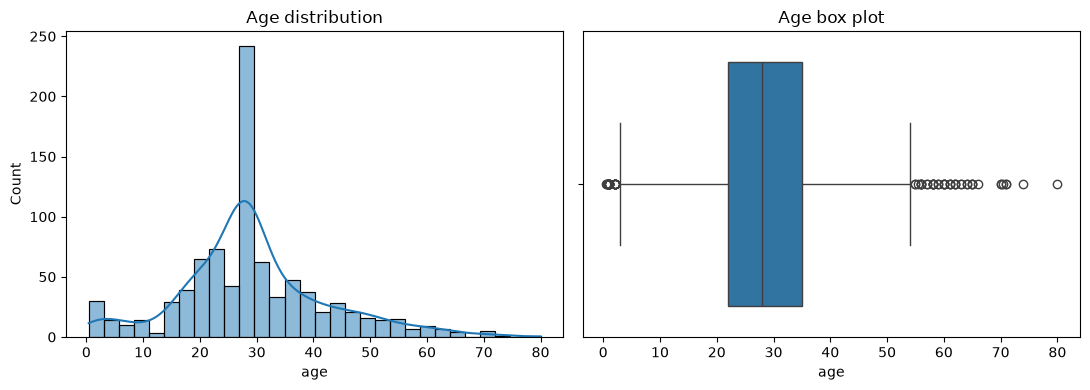

age outliers: 65


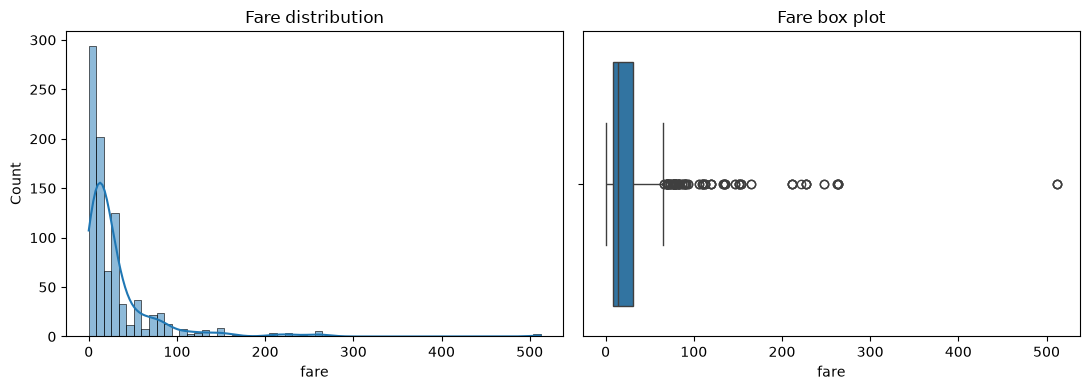

fare outliers: 114

Fare statistics:
Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05


In [5]:
for column in ["age", "fare"]:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sns.histplot(df[column], kde=True, ax=axes[0])
    axes[0].set_title(f"{column.title()} distribution")

    sns.boxplot(x=df[column], ax=axes[1])
    axes[1].set_title(f"{column.title()} box plot")

    plt.tight_layout()
    plt.savefig(CHARTS / f"{column}_distribution.png")
    plt.show()

    # Calculate outliers
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = (
        (df[column] < lower) |
        (df[column] > upper)
    ).sum()

    print(f"{column} outliers: {outliers}")

print("\nFare statistics:")
print("Mean:", df["fare"].mean())
print("Median:", df["fare"].median())
print("Mode:", df["fare"].mode().iloc[0])

In [6]:
# Survival by sex
for sex in df["sex"].unique():
    subset = df[df["sex"] == sex]
    print(sex, subset["survived"].mean() * 100)

# Survival by class
for pclass in sorted(df["pclass"].unique()):
    subset = df[df["pclass"] == pclass]

    print(
        "Class", pclass,
        subset["survived"].mean() * 100
    )

# Survival by sex and class
for sex in df["sex"].unique():
    for pclass in sorted(df["pclass"].unique()):
        subset = df[
            (df["sex"] == sex) &
            (df["pclass"] == pclass)
        ]

        print(
            sex, pclass,
            subset["survived"].mean() * 100
        )

male 18.890814558058924
female 74.03846153846155
Class 1 62.616822429906534
Class 2 47.28260869565217
Class 3 24.236252545824847
male 1 36.885245901639344
male 2 15.74074074074074
male 3 13.544668587896252
female 1 96.73913043478261
female 2 92.10526315789474
female 3 50.0


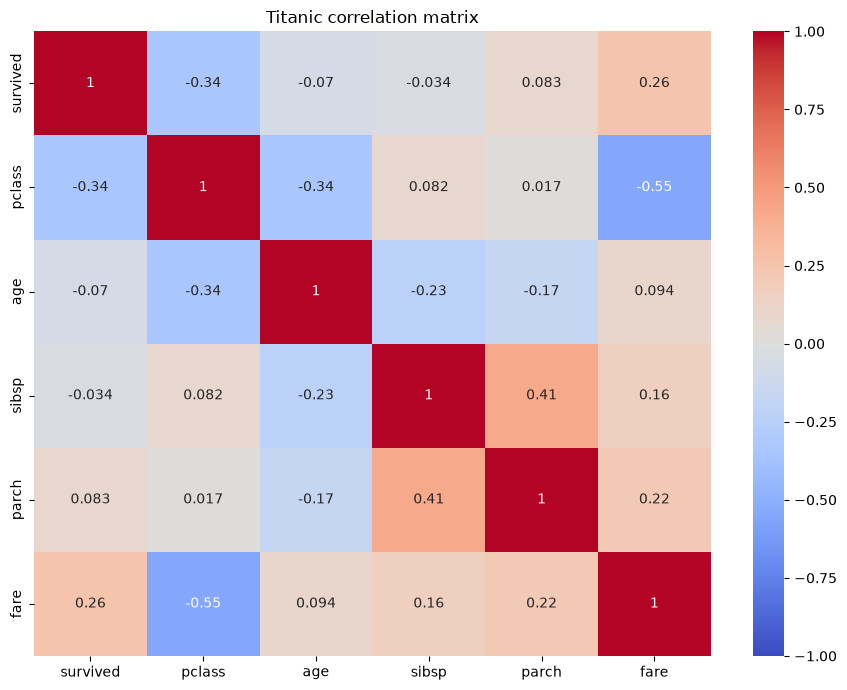

Two strongest correlations:
pclass  fare    -0.548193
sibsp   parch    0.414542
dtype: float64


In [7]:
columns = [
    "survived", "pclass", "age",
    "sibsp", "parch", "fare"
]

corr = df[columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Titanic correlation matrix")
plt.tight_layout()
plt.savefig(CHARTS / "correlation.png")
plt.show()

# Find the two strongest correlations
mask = np.triu(
    np.ones(corr.shape, dtype=bool),
    k=1
)

pairs = corr.where(mask).stack()

strongest = pairs.reindex(
    pairs.abs().sort_values(
        ascending=False
    ).index
).head(2)

print("Two strongest correlations:")
print(strongest)

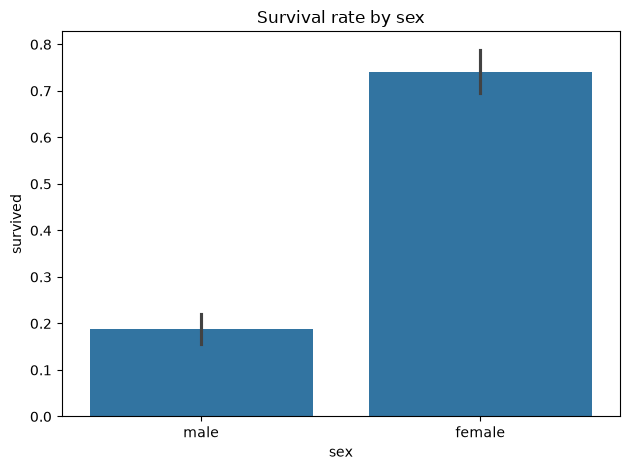

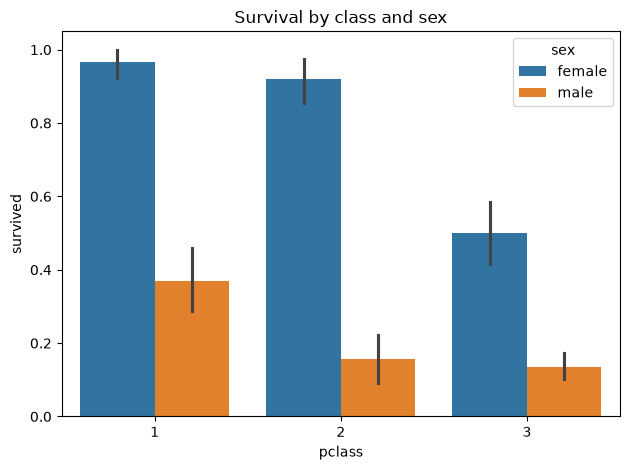

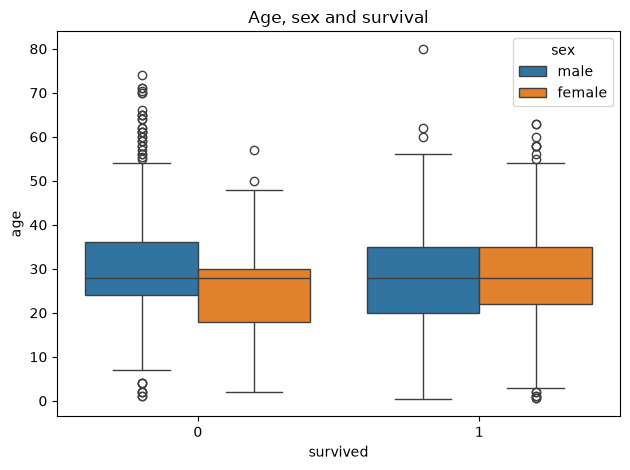

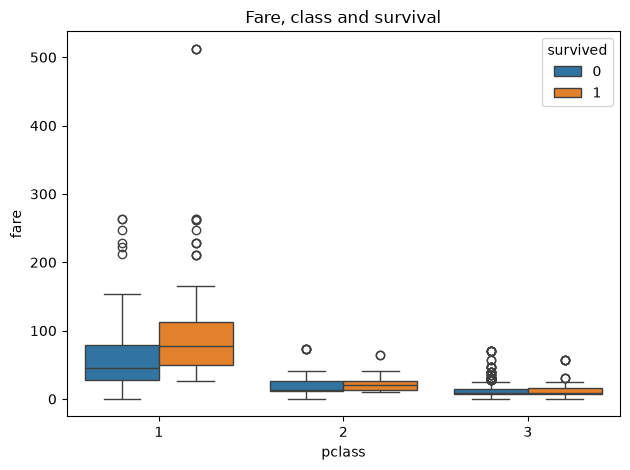

In [8]:
# Chart 1: Survival by sex
sns.barplot(data=df, x="sex", y="survived")
plt.title("Survival rate by sex")
plt.tight_layout()
plt.savefig(CHARTS / "survival_sex.png")
plt.show()

# Chart 2: Survival by class and sex
sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)
plt.title("Survival by class and sex")
plt.tight_layout()
plt.savefig(CHARTS / "survival_class_sex.png")
plt.show()

# Chart 3: Age by survival outcome
sns.boxplot(
    data=df,
    x="survived",
    y="age",
    hue="sex"
)
plt.title("Age, sex and survival")
plt.tight_layout()
plt.savefig(CHARTS / "age_survival.png")
plt.show()

# Chart 4: Fare by class and survival
sns.boxplot(
    data=df,
    x="pclass",
    y="fare",
    hue="survived"
)
plt.title("Fare, class and survival")
plt.tight_layout()
plt.savefig(CHARTS / "fare_class_survival.png")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(
    df[["age", "fare"]]
)

scaled_df = pd.DataFrame(
    scaled,
    columns=["age_scaled", "fare_scaled"]
)

print("Before standardization:")
print(df[["age", "fare"]].agg(["mean", "std"]))

print("\nAfter standardization:")
print(scaled_df.agg(["mean", "std"]))